In [1]:
# Test environment - CUDA GPU Training
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # Fix OpenMP duplicate library issue

import torch
print(f"PyTorch {torch.__version__} loaded successfully")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.10.0+cu128 loaded successfully
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


### Train PhoBERT Model

## Setup & Imports
Import necessary libraries and configure training environment

In [2]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, 
    recall_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', 'src'))

from dataset import FakeNewsDetectionDataset, FakeNewsDetectionDatasetCached
from model import HybridModel
from features import TextStyleExtractor
from rag_utils import RAGSearch
from augmentations import TextAugmentations

# Check CUDA availability
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU device:", torch.cuda.get_device_name(0))
print("="*60)

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU device: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
# ===== CONFIGURATION =====
# Model Configuration
MODEL_NAME = "vinai/phobert-base-v2"  # PhoBERT Expert
STYLE_DIM = 10
NUM_LABELS = 2
HIDDEN_DIM = 256
DROPOUT = 0.3

# Training Hyperparameters
MAX_LEN = 256  # PhoBERT-v2 max_position_embeddings=258 → max seq = 256
BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 400

# Early Stopping
EARLY_STOPPING_PATIENCE = 3  # Stop if val_f1 doesn't improve for 3 epochs

# CUDA Optimizations
USE_MIXED_PRECISION = True  # Enable FP16 for faster training on GPU
NUM_WORKERS = 0  # 0 for Windows compatibility
PIN_MEMORY = True  # Faster CPU-to-GPU transfer

# Data Configuration
DATA_DIR = "../../Organized"
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.2

# Checkpointing
CHECKPOINT_DIR = "../../checkpoints"
MODEL_SAVE_PATH = os.path.join(CHECKPOINT_DIR, "phobert_best.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Device Configuration & GPU Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)
print(f"MODEL: {MODEL_NAME}")
print(f"DEVICE: {device}")

# GPU Info
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU Memory: {gpu_memory:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Mixed Precision (FP16): {'Enabled' if USE_MIXED_PRECISION else 'Disabled'}")
else:
    print("No GPU detected - training will be slower on CPU")
    USE_MIXED_PRECISION = False

print(f"MAX LENGTH: {MAX_LEN} tokens (PhoBERT max=256)")
print(f"BATCH SIZE: {BATCH_SIZE}")
print(f"EPOCHS: {NUM_EPOCHS}")
print(f"EARLY STOPPING: patience={EARLY_STOPPING_PATIENCE}")
print(f"Data Workers: {NUM_WORKERS}")
print("=" * 60)

TRAINING CONFIGURATION
MODEL: vinai/phobert-base-v2
DEVICE: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Memory: 8.59 GB
CUDA Version: 12.8
Mixed Precision (FP16): Enabled
MAX LENGTH: 256 tokens (PhoBERT max=256)
BATCH SIZE: 16
EPOCHS: 10
EARLY STOPPING: patience=3
Data Workers: 0


## Dataset Preparation
Initialize RAG, Style Extractor, Augmentations, and create Dataset instances

In [4]:
# Initialize Text Augmentations (for training only)
print("Initializing Text Augmentations...")
text_augmentations = TextAugmentations(
    p_style_drop=0.1,
    p_bm25_drop=0.1,
    p_white_space=0.1,
    p_punctuation_noise=0.2,
    p_case_noise=0.15,
    p_teencode=0.3,
    p_accent_drop=0.2,
    p_features_drop=0.1
)

# Load cached dataset
PICKLE_PATH = "../cache_dataset.pkl"
assert os.path.exists(PICKLE_PATH), f"Cache not found: {PICKLE_PATH}. Run build_dataset_cache.py first."
print(f"Loading cached dataset from {PICKLE_PATH}...")

full_dataset = FakeNewsDetectionDatasetCached(
    pickle_path=PICKLE_PATH,
    text_augmentations=text_augmentations,
    tokenizer_name=MODEL_NAME,
    max_len=MAX_LEN
)

print(f"Total samples: {len(full_dataset)}")

# Split into train and validation
train_size = int(TRAIN_SPLIT * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Disable augmentation for validation
print("Creating validation dataset (no augmentation)...")
val_dataset_clean = FakeNewsDetectionDatasetCached(
    pickle_path=PICKLE_PATH,
    text_augmentations=None,
    tokenizer_name=MODEL_NAME,
    max_len=MAX_LEN
)
val_dataset = torch.utils.data.Subset(val_dataset_clean, val_dataset.indices)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Create DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,
    pin_memory=PIN_MEMORY,
)

print("Dataset ready!")

Initializing Text Augmentations...
Loading cached dataset from ../cache_dataset.pkl...
Total samples: 5579
Creating validation dataset (no augmentation)...
Train samples: 4463
Validation samples: 1116
Dataset ready!


## Model Initialization
Create the HybridModel with PhoBERT backbone

In [5]:
# Initialize model
model = HybridModel(
    model_name=MODEL_NAME,
    style_dim=STYLE_DIM,
    num_labels=NUM_LABELS,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
)

# FIX: Resize token embeddings to match tokenizer vocab size
from transformers import AutoTokenizer
tokenizer_fix = AutoTokenizer.from_pretrained(MODEL_NAME)
model.bert.resize_token_embeddings(len(tokenizer_fix))
print(f"✓ Resized model embeddings to match tokenizer: {len(tokenizer_fix)} tokens")

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (AdamW with weight decay)
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
from transformers import get_linear_schedule_with_warmup

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

# Mixed Precision Scaler (for FP16 training)
if USE_MIXED_PRECISION and torch.cuda.is_available():
    from torch.cuda.amp import autocast, GradScaler
    scaler = GradScaler()
    print("Mixed Precision (FP16) enabled - 2x faster training!")
else:
    scaler = None
    print("Using FP32 precision")

print("Model initialized and ready for training")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[INFO] HybridModel initialized with vinai/phobert-base-v2
[INFO] Fusion dimension: 768 (BERT) + 10 (Style) = 778


✓ Resized model embeddings to match tokenizer: 64001 tokens
Total Parameters: 135,230,850
Trainable Parameters: 135,230,850
Mixed Precision (FP16) enabled - 2x faster training!
Model initialized and ready for training


C:\Users\Dat\AppData\Local\Temp\ipykernel_24636\1880553003.py:48: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## Training Loop
Full end-to-end training with validation and checkpointing

In [6]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device, scaler=None):
    """Train for one epoch with optional mixed precision"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        style_vector = batch['style_vector'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        if scaler is not None:
            with autocast():
                logits = model(input_ids, attention_mask, style_vector)
                loss = criterion(logits, labels)
            
            # Scaled backward pass
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            # Regular FP32 training
            logits = model(input_ids, attention_mask, style_vector)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy, all_preds, all_labels


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            style_vector = batch['style_vector'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)
            
            # Forward pass
            logits = model(input_ids, attention_mask, style_vector)
            loss = criterion(logits, labels)
            
            # Track metrics
            total_loss += loss.item()
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(logits, dim=-1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    
    return avg_loss, accuracy, f1, precision, recall, all_preds, all_labels

print("Training functions defined (GPU-optimized with mixed precision support)")

Training functions defined (GPU-optimized with mixed precision support)


In [7]:
from transformers import logging
logging.set_verbosity_error()

import copy
from typing import Any

print("Starting training...")
print(f"Training on: {device}")
if USE_MIXED_PRECISION and device.type == 'cuda':
    print("Using mixed precision (FP16) training for 2x speedup")

history: dict[str, Any] = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [],
    'val_precision': [], 'val_recall': []
}

best_val_f1 = 0.0
best_model_state = None
patience_counter = 0

print("\n" + "="*60)
print(f"TRAINING WITH EARLY STOPPING (patience={EARLY_STOPPING_PATIENCE})")
print("="*60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-"*60)
    
    # ===== TRAIN =====
    train_loss, train_acc, train_preds, train_labels = train_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        scaler=scaler if USE_MIXED_PRECISION and device.type == 'cuda' else None
    )
    
    # ===== VALIDATE =====
    val_loss, val_acc, val_f1, val_precision, val_recall, val_preds, val_labels = validate_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
    
    # ===== EARLY STOPPING CHECK =====
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f">>> New best Val F1: {best_val_f1:.4f} — model saved!")
    else:
        patience_counter += 1
        print(f">>> No improvement ({patience_counter}/{EARLY_STOPPING_PATIENCE})")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}!")
            break

# ===== SAVE BEST MODEL =====
print("\n" + "="*60)
if best_model_state is not None:
    model.load_state_dict(best_model_state)

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_f1': best_val_f1,
    'history': history,
}, MODEL_SAVE_PATH)
print(f"Best model saved to '{MODEL_SAVE_PATH}'")
print(f"Best Val F1: {best_val_f1:.4f}")
print(f"Trained for {len(history['train_loss'])} epochs")
print("="*60)

Starting training...
Training on: cuda
Using mixed precision (FP16) training for 2x speedup

TRAINING WITH EARLY STOPPING (patience=3)

Epoch 1/10
------------------------------------------------------------


Training:   0%|          | 0/279 [00:00<?, ?it/s]C:\Users\Dat\AppData\Local\Temp\ipykernel_24636\2015734569.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 70/70 [00:08<00:00,  7.91it/s, loss=0.4516]


Train Loss: 0.6233 | Train Acc: 0.6883
Val   Loss: 0.5059 | Val   Acc: 0.8011 | Val F1: 0.7996
>>> New best Val F1: 0.7996 — model saved!

Epoch 2/10
------------------------------------------------------------


Training:   0%|          | 0/279 [00:00<?, ?it/s]C:\Users\Dat\AppData\Local\Temp\ipykernel_24636\2015734569.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 70/70 [00:09<00:00,  7.75it/s, loss=0.1003]


Train Loss: 0.3802 | Train Acc: 0.8772
Val   Loss: 0.4216 | Val   Acc: 0.8701 | Val F1: 0.8661
>>> New best Val F1: 0.8661 — model saved!

Epoch 3/10
------------------------------------------------------------


...

Train Loss: 0.0617 | Train Acc: 0.9872
Val   Loss: 0.1947 | Val   Acc: 0.9588 | Val F1: 0.9588
>>> No improvement (1/3)

Epoch 8/10
------------------------------------------------------------


Training:   0%|          | 0/279 [00:00<?, ?it/s]C:\Users\Dat\AppData\Local\Temp\ipykernel_24636\2015734569.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 70/70 [00:09<00:00,  7.63it/s, loss=0.0012]


Train Loss: 0.0374 | Train Acc: 0.9926
Val   Loss: 0.2535 | Val   Acc: 0.9579 | Val F1: 0.9577
>>> No improvement (2/3)

Epoch 9/10
------------------------------------------------------------


Training:   0%|          | 0/279 [00:00<?, ?it/s]C:\Users\Dat\AppData\Local\Temp\ipykernel_24636\2015734569.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 70/70 [00:09<00:00,  7.72it/s, loss=0.0011]


Train Loss: 0.0387 | Train Acc: 0.9928
Val   Loss: 0.2257 | Val   Acc: 0.9615 | Val F1: 0.9614
>>> No improvement (3/3)

Early stopping triggered at epoch 9!

Best model saved to '../../checkpoints\phobert_best.pth'
Best Val F1: 0.9623
Trained for 9 epochs


## Evaluation & Visualization
Load best model and generate detailed metrics

In [8]:
# Load best model
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
history = checkpoint['history']
print(f"Loaded best model from {MODEL_SAVE_PATH}")

# Final evaluation on validation set
val_loss, val_acc, val_f1, val_precision, val_recall, final_preds, final_labels = validate_epoch(
    model, val_loader, criterion, device
)

print("\n" + "=" * 60)
print("FINAL VALIDATION METRICS")
print("=" * 60)
print(f"Accuracy:  {val_acc:.4f}")
print(f"F1 Score:  {val_f1:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print("=" * 60)

# Detailed classification report
# Label 0 = FAKE, Label 1 = REAL
print("\nClassification Report:")
print(classification_report(final_labels, final_preds, target_names=['Fake', 'Real']))

Loaded best model from ../../checkpoints\phobert_best.pth


Validation: 100%|██████████| 70/70 [00:09<00:00,  7.25it/s, loss=0.0038]


FINAL VALIDATION METRICS
Accuracy:  0.9624
F1 Score:  0.9623
Precision: 0.9627
Recall:    0.9624

Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.94      0.96       493
        Real       0.95      0.98      0.97       623

    accuracy                           0.96      1116
   macro avg       0.96      0.96      0.96      1116
weighted avg       0.96      0.96      0.96      1116



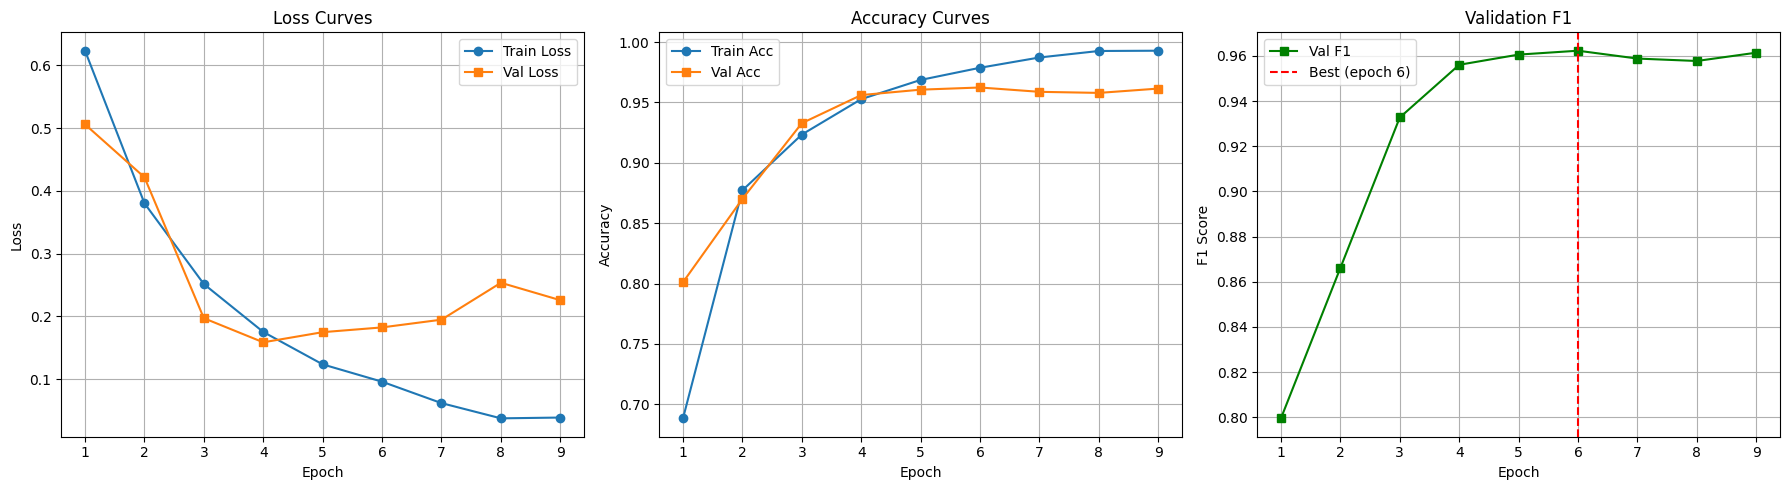

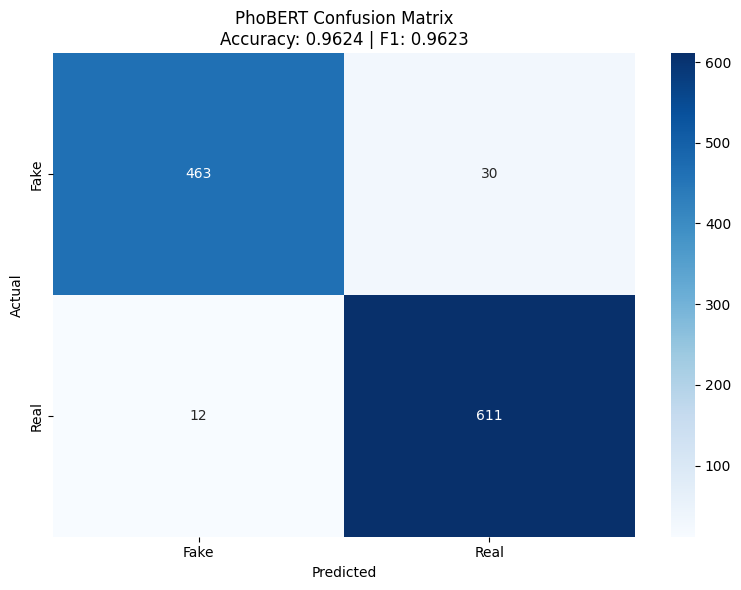


Plots saved to ../../checkpoints/


In [9]:
# Plot training curves (train + val per epoch)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(epochs_range, history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(epochs_range, history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].legend()
axes[1].grid(True)

# F1 curve
axes[2].plot(epochs_range, history['val_f1'], label='Val F1', marker='s', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Validation F1')
best_epoch = int(np.argmax(history['val_f1'])) + 1
axes[2].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'phobert_training_curves.png'), dpi=150)
plt.show()

# Confusion matrix
# Label 0 = FAKE, Label 1 = REAL
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'PhoBERT Confusion Matrix\nAccuracy: {val_acc:.4f} | F1: {val_f1:.4f}')
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'phobert_confusion_matrix.png'), dpi=150)
plt.show()

print(f"\nPlots saved to {CHECKPOINT_DIR}/")